# Navier Stokes Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Isothermal Navier-Stokes equation using the multi-trajectory (Part 1) workflow.

## Governing equations

The isothermal compressible Navier–Stokes equations are

$$
\begin{aligned}
\partial_t \rho + \nabla \cdot (\rho \mathbf{u}) &= 0 \\
\partial_t (\rho \mathbf{u}) + \nabla \cdot (\rho \mathbf{u}\otimes \mathbf{u}) + \nabla p &= \mu \Delta \mathbf{u},
\end{aligned}
$$

where $\rho(\mathbf{x},t)$ is the density, $\mathbf{u}(\mathbf{x},t)$ is the velocity field, $p$ is the pressure, and $\mu$ is the viscosity coefficient. Under the isothermal ideal-gas assumption, the pressure is given by the equation of state

$$
p = \rho R T,
$$

where $R$ is the specific gas constant and $T$ is the constant temperature

We use parameters $(\mu, c_s)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.isothermal_flow import (
    NSIsothermalMultiTrajectoryGLSConfig,
    generate_isothermal_ns_dataset,
    run_ns_isothermal_multi_trajectory_gls_experiment,
)
from mfsindy.cases.isothermal_flow_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]


In [2]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

# cfg = NSIsothermalMultiTrajectoryGLSConfig(
#     n_runs=25,          # increase if compute budget allows
#     n_lf=10,
#     n_hf=1,
#     noise_lf_rel=0.025,
#     noise_hf_rel=0.001,
#     N=64,
#     Nt=100,            
#     Nt_std=500,      
#     L=5.0,
#     T=0.1,
#     T_std = 0.5,
#     mu=1.0,
#     RT=1.0,
#     derivative_order=2,
#     include_bias=False,
#     p=2,
#     K=500,
#     K_std=100,
#     stlsq_threshold=0.5,
#     stlsq_alpha=1e-12,
#     n_ensemble_models=100,
#     seed_base=0,
#     results_dir="results",
#     results_filename="temp.csv",
# )

cfg = NSIsothermalMultiTrajectoryGLSConfig(
    n_runs=1,          # increase if compute budget allows
    n_lf=10,
    n_hf=1,
    noise_lf_rel=0.25,
    noise_hf_rel=0.01,
    N=64,
    Nt=50,            
    Nt_std=500,      
    L=5.0,
    T=0.5,
    T_std = 0.5,
    mu=1.0,
    RT=1.0,
    derivative_order=2,
    include_bias=False,
    p=2,
    K=100,
    K_std=100,
    stlsq_threshold=0.5,
    stlsq_alpha=1e-12,
    n_ensemble_models=100,
    seed_base=0,
    results_dir="results",
    results_filename="temp.csv",
)

print(
    f"Running Part 1 Navier-Stokes experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_ns_isothermal_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)


Running Part 1 Navier-Stokes experiment with n_LF=10, n_HF=1, noise_rel(LF)=0.25, noise_rel(HF)=0.01.
(x0)' = -1.000 x1x0_2 +  1.005 x2^-1x0_22 + -1.000 x0x0_1 + -1.000 x2^-1x2_1 +  1.000 x2^-1x0_11
(x1)' = -1.004 x1x1_2 + -1.003 x2^-1x2_2 +  1.000 x2^-1x1_22 + -0.998 x0x1_1 +  1.000 x2^-1x1_11
(x2)' = -1.000 x2x1_2 + -1.000 x1x2_2 + -1.000 x2x0_1 + -1.000 x0x2_1
(x0)' = -0.997 x1x0_2 +  1.004 x2^-1x0_22 + -1.000 x0x0_1 + -1.000 x2^-1x2_1 +  1.000 x2^-1x0_11
(x1)' = -1.014 x1x1_2 + -1.003 x2^-1x2_2 +  1.002 x2^-1x1_22 + -0.997 x0x1_1 +  0.996 x2^-1x1_11
(x2)' = -1.000 x2x1_2 + -1.000 x1x2_2 + -1.000 x2x0_1 + -1.000 x0x2_1
0.6347992788817043
[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.         -1.00010482  0.
   0.          0.          0.          0.          0.          0.
   0.          0.    

MC isothermal NS MF:   0%|          | 0/1 [00:00<?, ?it/s]

FIT
MODEL HF:
(x0)' = -1.766 x0 + -0.773 x0x0_1
(x1)' =  0.943 x2^-1x1_22
(x2)' =  0.000
MODEL LF:
(x0)' = -2.035 x0 +  0.944 x1_2 + -2.233 x1_1 + -0.959 x1x0_2 +  2.382 x2x1_1
(x1)' = -3.372 x1 + -2.949 x0_2 + -0.705 x0_1 + -1.136 x1x0_2 + -0.730 x1x1_2
(x2)' = -1.002 x2x1_2 + -1.024 x1x2_2 + -0.978 x2x0_1 + -0.952 x0x2_1
MODEL MF:
(x0)' = -1.973 x0 +  0.960 x1_2 + -2.090 x1_1 + -0.543 x2_1 +  2.326 x2x1_1
(x1)' = -3.433 x1 + -2.761 x0_2 + -0.805 x0_1 + -1.254 x1x0_2 + -0.726 x1x1_2
(x2)' = -1.000 x2x1_2 + -0.991 x1x2_2 + -0.972 x2x0_1 + -0.951 x0x2_1
(11, 64, 64, 50, 1)


MC isothermal NS MF: 100%|██████████| 1/1 [00:32<00:00, 32.95s/it]

MODEL MFW:
(x0)' = -2.016 x0 +  0.982 x1_2 + -0.582 x0_1 + -1.729 x1_1 + -0.548 x1x0_2 +  0.593 x2x0_1 +  2.213 x2x1_1
(x1)' = -3.147 x1 + -2.924 x0_2 + -0.804 x0_1 + -0.677 x1x1_2
(x2)' = -0.993 x2x1_2 + -1.003 x1x2_2 + -0.985 x2x0_1 + -0.951 x0x2_1


In [3]:
print("Mean Absolute Error")
print(mae_summary)


Mean Absolute Error
         median       q25       q75
model                              
HF     0.042222  0.042222  0.042222
LF     0.072592  0.072592  0.072592
MF     0.076615  0.076615  0.076615
MF_w   0.071620  0.071620  0.071620


In [4]:
print("Support Fraction Error")
print(l0_summary)


Support Fraction Error
         median       q25       q75
model                              
HF     0.928571  0.928571  0.928571
LF     1.142857  1.142857  1.142857
MF     1.285714  1.285714  1.285714
MF_w   1.214286  1.214286  1.214286


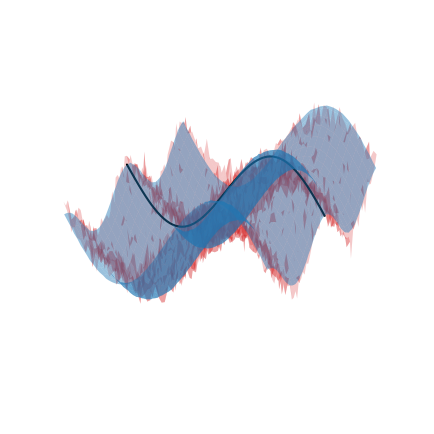

In [5]:
# --- Reference dataset just for noise scaling -------------------------
U_ref, t_ref, grid_ref = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=cfg.seed_base,
    ic_type="taylor-green",
)
state_std    = float(np.std(U_ref))
noise_hf_abs = cfg.noise_hf_rel * state_std
noise_lf_abs = cfg.noise_lf_rel * state_std

# --- One HF and one LF trajectory with homoscedastic noise -----------
rng_hf = np.random.default_rng(cfg.seed_base + 1000)
rng_lf = np.random.default_rng(cfg.seed_base + 2000)

U_hf_clean, t, grid = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=cfg.seed_base + 10,
    ic_type="taylor-green",
)
U_lf_clean, _, _ = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=cfg.seed_base + 20,
    ic_type="taylor-green",
)

U_hf_noisy = U_hf_clean + noise_hf_abs * rng_hf.standard_normal(U_hf_clean.shape)
U_lf_noisy = U_lf_clean + noise_lf_abs * rng_lf.standard_normal(U_lf_clean.shape)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# choose a representative time index (e.g. middle of the window)
k_mid = 0  # fixed time index

# u(x,y,t_k) for HF / LF / reference
u_hf  = U_hf_noisy[:, :, k_mid, 0]   # (Nx, Ny)
u_lf  = U_lf_noisy[:, :, k_mid, 0]   # (Nx, Ny)
u_ref = U_ref[:,     :, k_mid, 0]    # (Nx, Ny)

# corresponding spatial grid at that time
x = grid[:, :, k_mid, 0]   # (Nx, Ny)
y = grid[:, :, k_mid, 1]   # (Nx, Ny)

# --- 3D compact panel -------------------------------------------------
fig = plt.figure(figsize=(5, 3.5), dpi=150)
ax = fig.add_subplot(111, projection="3d")

# LF surface (red, more transparent)
ax.plot_surface(
    x, y, u_lf,
    color="tab:red",
    alpha=0.25,
    linewidth=0,
    antialiased=True,
    shade=False,
)

# HF surface (blue, less transparent)
ax.plot_surface(
    x, y, u_hf,
    color="tab:blue",
    alpha=0.45,
    linewidth=0,
    antialiased=True,
    shade=False,
)

# Reference ridge along a line (e.g. mid-y)
j_mid = cfg.N // 2
ax.plot(
    x[:, j_mid],
    y[:, j_mid],
    u_ref[:, j_mid],
    color="black",
    linewidth=1.0,
)

# Remove ticks / axes for table-friendly panel
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.set_axis_off()
ax.grid(False)


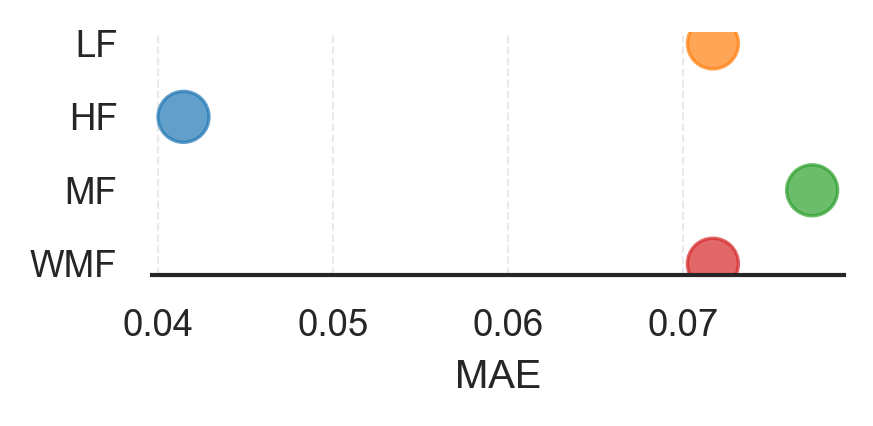

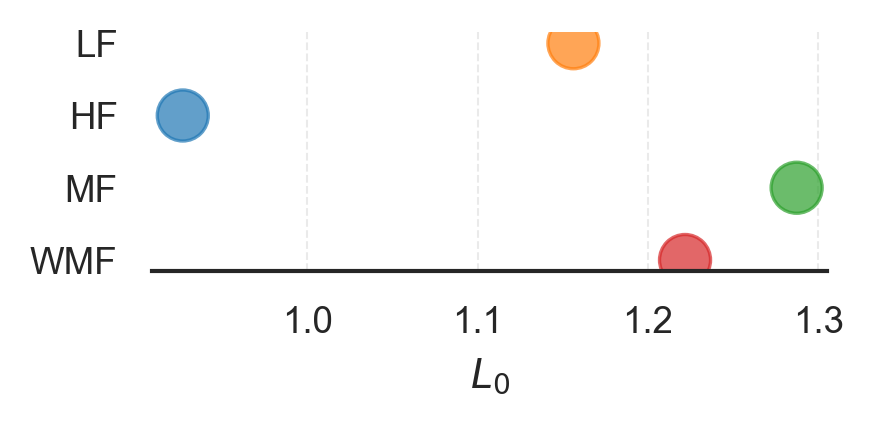

In [6]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

